# PyTorch training step by step / Adım adım PyTorch eğitimi

**English**

- **Goal:** predict grades from study hours with a simple linear regression.
- **Model:** manually defined trainable weight and bias, `y_hat = weight * x + bias`.
- **Roadmap:** inspect data → create tensors → split data → define the model → train and evaluate → inspect losses and parameters.
- Run the code cells from top to bottom. Each explanation describes the code immediately below it.

**Türkçe**

- **Amaç:** basit doğrusal regresyonla çalışma süresinden not tahmin etmek.
- **Model:** elle tanımlanmış öğrenilebilir ağırlık ve bias, `y_hat = weight * x + bias`.
- **Akış:** veriyi incele → tensörleri oluştur → veriyi ayır → modeli tanımla → eğit ve değerlendir → kayıpları ve parametreleri incele.
- Kod hücrelerini yukarıdan aşağıya çalıştır. Her açıklama hemen altındaki kodu anlatır.


## 1. Import libraries / Kütüphaneleri içe aktar

**English**

Pandas reads and inspects tabular data. PyTorch provides tensors and training tools; Matplotlib draws the graphs.

**Türkçe**

Pandas tablo verisini okur ve inceler. PyTorch tensörleri ve eğitim araçlarını sağlar; Matplotlib grafikleri çizer.


In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

## 2. Load the dataset / Veri setini yükle

**English**

Read the CSV into `df`. The relative path assumes the notebook runs from this folder. `study_hours` is the input and `grade` is the value to predict.

**Türkçe**

CSV dosyasını `df` içine oku. Göreli yol, notebook’un bu klasörden çalıştırıldığını varsayar. `study_hours` girdidir; `grade` tahmin edilecek değerdir.


In [2]:
df = pd.read_csv("../data/06-study_hours_grades.csv")

## 3. Inspect the table / Tabloyu incele

**English**

Display `df` to inspect the column names and values before preparing the model inputs. Large tables may be truncated in the display.

**Türkçe**

Model girdilerini hazırlamadan önce sütun adlarını ve değerleri görmek için `df` tablosunu göster. Büyük tablolar ekranda kısaltılabilir.


In [3]:
df

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888
5,1.559945,16.360038
6,0.580836,11.982903
7,8.661761,55.423052
8,6.011150,40.742987
9,7.080726,41.877549


## 4. Check column types / Sütun türlerini kontrol et

**English**

`df.info()` reports column types and non-null counts. Use these to check whether the inputs are numeric and whether values are missing.

**Türkçe**

`df.info()` sütun türlerini ve boş olmayan değer sayılarını gösterir. Girdilerin sayısal olup olmadığını ve eksik değer bulunup bulunmadığını kontrol et.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


## 5. Inspect statistics / İstatistikleri incele

**English**

`df.describe()` summarizes numeric columns with counts, means, standard deviations, quartiles, and minimum/maximum values. This helps you understand the data scale.

**Türkçe**

`df.describe()` sayısal sütunların adet, ortalama, standart sapma, çeyreklik ve minimum/maksimum değerlerini özetler. Böylece verinin ölçeğini anlarsın.


In [5]:
df.describe()

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


## 6. Create tensors / Tensörleri oluştur

**English**

Convert the input and target columns into `X` and `y`. These are one-dimensional tensors of shape `(N,)`. No dtype is specified, so PyTorch infers it from the NumPy arrays; numeric data may therefore become `float64` rather than `float32`.

**Türkçe**

Girdi ve hedef sütunlarını `X` ve `y` tensörlerine dönüştür. Bunlar `(N,)` şeklinde tek boyutlu tensörlerdir. `dtype` belirtilmediği için PyTorch türü NumPy dizilerinden çıkarır; sayısal veri bu nedenle `float32` yerine `float64` olabilir.


In [6]:
X = torch.tensor(df["study_hours"].values)
y = torch.tensor(df["grade"].values)

## 7. Inspect inputs / Girdileri incele

**English**

Display `X`: each value represents the study hours of one sample. Check the values and the displayed dtype.

**Türkçe**

`X` tensörünü göster: her değer bir örneğin çalışma süresini temsil eder. Değerleri ve gösterilen veri türünü kontrol et.


In [7]:
X

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

## 8. Inspect targets / Hedefleri incele

**English**

Display `y`: each grade is paired with the study-hours value at the same index in `X`.

**Türkçe**

`y` tensörünü göster: her not, `X` içindeki aynı indeksteki çalışma süresiyle eşleşir.


In [8]:
y

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325,
        15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

## 9. Choose the split point / Ayırma noktasını belirle

**English**

`int(len(X) * 0.8)` computes the number of training samples, rounding down. The remaining samples form the test set.

**Türkçe**

`int(len(X) * 0.8)` eğitim örneği sayısını aşağı yuvarlayarak hesaplar. Kalan örnekler test kümesini oluşturur.


In [9]:
train_split = int(len(X) * 0.8)

## 10. Build the training set / Eğitim kümesini oluştur

**English**

Select the first `train_split` samples from both tensors. Matching slices keep each input aligned with its target. There is no shuffling: the original row order is preserved.

**Türkçe**

Her iki tensörün ilk `train_split` örneğini seç. Aynı dilimler her girdiyi kendi hedefiyle eşleştirir. Karıştırma yapılmaz; başlangıçtaki satır sırası korunur.


In [10]:
X_train = X[:train_split]
y_train = y[:train_split]

## 11. Inspect training inputs / Eğitim girdilerini incele

**English**

Display `X_train`, the study-hours values that will be used to compute predictions during training.

**Türkçe**

Eğitim sırasında tahmin hesaplamak için kullanılacak çalışma sürelerini, yani `X_train` tensörünü göster.


In [11]:
X_train

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015], dtype=torch.float64)

## 12. Inspect training targets / Eğitim hedeflerini incele

**English**

Display `y_train`, the true grades used to measure the training prediction error.

**Türkçe**

Eğitim tahminlerinin hatasını ölçmek için kullanılan gerçek notları, yani `y_train` tensörünü göster.


In [12]:
y_train

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325],
       dtype=torch.float64)

## 13. Build the test set / Test kümesini oluştur

**English**

Select the samples from `train_split` onward. Their loss will be measured without updating the model from these samples. An ordered split may produce different train/test distributions if the CSV is sorted.

**Türkçe**

`train_split` indeksinden sonraki örnekleri seç. Bu örneklerle model güncellenmeden hata ölçülecek. CSV sıralıysa bu ayırma yöntemi eğitim/test dağılımlarının farklı olmasına yol açabilir.


In [13]:
X_test = X[train_split:]
y_test = y[train_split:]

## 14. Visualize the split / Veri ayrımını görselleştir

**English**

Plot study hours on the horizontal axis and grades on the vertical axis for each subset. `label` names the series, but this cell does not call `plt.legend()`, so those labels are not shown as a legend.

**Türkçe**

Her alt küme için yatay eksende çalışma süresini, dikey eksende notları çiz. `label` serileri adlandırır; bu hücre `plt.legend()` çağırmadığı için etiketler açıklama kutusunda gösterilmez.


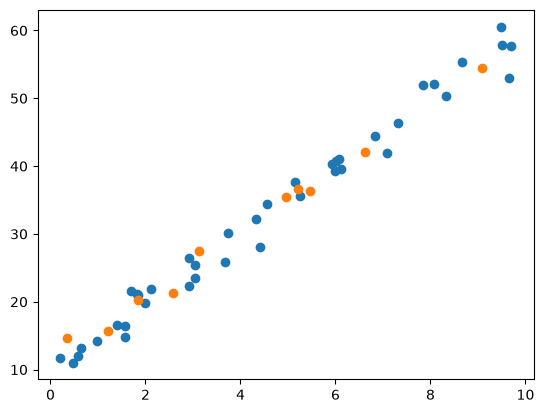

In [16]:
plt.scatter(X_train, y_train, label="Training Dataset")
plt.scatter(X_test, y_test, label="Test Dataset")
plt.show()

## 15. Define the model manually / Modeli elle tanımla

**English**

`nn.Module` is the base class for PyTorch models. `super().__init__()` initializes it. `nn.Parameter` registers the random weight and bias as trainable parameters; `requires_grad=True` enables gradient tracking. `forward()` computes `y_hat = weight * x + bias` for every input. Calling the model invokes this method.

**Türkçe**

`nn.Module`, PyTorch modellerinin temel sınıfıdır. `super().__init__()` bu sınıfı başlatır. `nn.Parameter`, rastgele ağırlık ve bias değerlerini öğrenilebilir parametre olarak kaydeder; `requires_grad=True` gradyan takibini açar. `forward()` her girdi için `y_hat = weight * x + bias` hesaplar. Model çağrıldığında bu metot çalışır.


In [17]:
from torch import nn

class SimpleLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

## 16. Initialize reproducibly / Tekrarlanabilir başlangıç oluştur

**English**

Set the PyTorch random seed before constructing `model_0` so that repeating these cells in the same environment gives the same initial random parameters. The model has not learned from the dataset yet.

**Türkçe**

Aynı ortamda bu hücreler tekrarlandığında başlangıç parametreleri aynı olsun diye `model_0` oluşturulmadan önce PyTorch rastgelelik tohumunu ayarla. Model henüz veri setinden öğrenmedi.


In [34]:
torch.manual_seed(42)

model_0 = SimpleLinearRegressionModel()

## 17. Inspect trainable parameters / Öğrenilebilir parametreleri incele

**English**

`model_0.parameters()` yields the registered parameters; converting it to a list displays the weight and bias. These are the values the optimizer will update.

**Türkçe**

`model_0.parameters()` kayıtlı parametreleri verir; listeye çevirmek ağırlık ve bias değerlerini gösterir. Optimizer bu değerleri güncelleyecek.


In [35]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

## 18. Inspect the initial state / Başlangıç durumunu incele

**English**

`state_dict()` returns named parameters and any persistent buffers. Here it shows the initial `weights` and `bias`; displaying it does not save a file.

**Türkçe**

`state_dict()` adlandırılmış parametreleri ve varsa kalıcı tamponları döndürür. Burada başlangıçtaki `weights` ve `bias` görünür; bunu göstermek dosyaya kayıt yapmaz.


In [36]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## 19. Choose loss and optimizer / Kayıp ve optimizer seç

**English**

`nn.MSELoss()` averages the squared differences between predictions and true grades. SGD updates the model parameters using their gradients. `lr=0.001` controls the update size; the goal is to reduce the loss.

**Türkçe**

`nn.MSELoss()` tahminlerle gerçek notlar arasındaki farkların karelerinin ortalamasını hesaplar. SGD, gradyanları kullanarak model parametrelerini günceller. `lr=0.001` güncelleme büyüklüğünü kontrol eder; amaç kaybı azaltmaktır.


In [37]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.001)

## 20. Train and evaluate step by step / Adım adım eğit ve değerlendir

**English**

Run 250 epochs with the entire training set in each update (full-batch training). The seed is set again, but this does not reinitialize the existing model.

1. `model_0.train()` sets training mode; it does not perform training by itself.
2. `model_0(X_train)` makes predictions (forward pass).
3. `loss_fn(...)` computes the training MSE.
4. `optimizer.zero_grad()` clears previous gradients because PyTorch accumulates them.
5. `loss.backward()` computes gradients of the loss with respect to the parameters.
6. `optimizer.step()` updates the weight and bias.
7. `eval()` sets evaluation mode; `inference_mode()` disables gradient tracking for test predictions. Neither updates parameters.
8. Every five epochs, store the epoch and both losses and print progress. `detach().numpy()` turns a CPU tensor into a NumPy value without gradient tracking.

The training loss is computed **before** the update; the test loss is computed **after** it. The test set is checked repeatedly here; a separate validation set is preferable when tuning choices, keeping a final test set for the end.

**Türkçe**

250 epoch çalıştır; her güncellemede eğitim kümesinin tamamını kullan (full-batch eğitim). Tohum yeniden ayarlanır ancak mevcut modelin parametreleri yeniden başlatılmaz.

1. `model_0.train()` eğitim modunu açar; tek başına eğitim yapmaz.
2. `model_0(X_train)` tahminleri üretir (ileri yayılım).
3. `loss_fn(...)` eğitim MSE değerini hesaplar.
4. `optimizer.zero_grad()` önceki gradyanları temizler; çünkü PyTorch gradyanları biriktirir.
5. `loss.backward()` kaybın parametrelere göre gradyanlarını hesaplar.
6. `optimizer.step()` ağırlığı ve bias değerini günceller.
7. `eval()` değerlendirme modunu açar; `inference_mode()` test tahminlerinde gradyan takibini kapatır. İkisi de parametre güncellemez.
8. Her beş epoch’ta epoch ve iki kayıp değerini kaydet, ilerlemeyi yazdır. `detach().numpy()` CPU tensörünü gradyan takibi olmadan NumPy değerine çevirir.

Eğitim kaybı güncellemeden **önce**, test kaybı güncellemeden **sonra** hesaplanır. Burada test kümesi tekrar tekrar kontrol edilir; seçimleri ayarlarken ayrı bir doğrulama kümesi kullanmak ve son test kümesini en sona bırakmak daha uygundur.


In [38]:
torch.manual_seed(42)

epochs = 250
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred, y_test)

        if epoch % 5 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch}, Train Loss: {loss}, Test Loss: {test_loss}")

Epoch: 0, Train Loss: 1156.0767463081781, Test Loss: 858.3088765088272
Epoch: 5, Train Loss: 633.9334744710083, Test Loss: 484.2837829868178
Epoch: 10, Train Loss: 352.99125276114285, Test Loss: 280.90521005460033
Epoch: 15, Train Loss: 201.80191856738534, Test Loss: 169.8918797355706
Epoch: 20, Train Loss: 120.41268871324436, Test Loss: 108.98031233032034
Epoch: 25, Train Loss: 76.57232180621143, Test Loss: 75.32370882849361
Epoch: 30, Train Loss: 52.931428428694815, Test Loss: 56.55033419714631
Epoch: 35, Train Loss: 40.157054153236494, Test Loss: 45.9453113422317
Epoch: 40, Train Loss: 33.22852214719357, Test Loss: 39.85290344471839
Epoch: 45, Train Loss: 29.44508410079029, Test Loss: 36.274774134597365
Epoch: 50, Train Loss: 27.353844189863754, Test Loss: 34.11265188608324
Epoch: 55, Train Loss: 26.173217192098285, Test Loss: 32.75872353470674
Epoch: 60, Train Loss: 25.482772613444595, Test Loss: 31.87363984152036
Epoch: 65, Train Loss: 25.05632900940991, Test Loss: 31.265739395147

## 21. Plot the loss curves / Kayıp eğrilerini çiz

**English**

Plot the recorded training and test MSE against epoch numbers. Values were stored every five epochs, not every epoch. Falling loss indicates lower prediction error; persistently diverging curves can suggest poor generalization.

**Türkçe**

Kaydedilen eğitim ve test MSE değerlerini epoch numaralarına göre çiz. Değerler her epoch’ta değil, beş epoch’ta bir kaydedildi. Azalan kayıp daha düşük tahmin hatasını gösterir; sürekli ayrışan eğriler genelleme sorununa işaret edebilir.


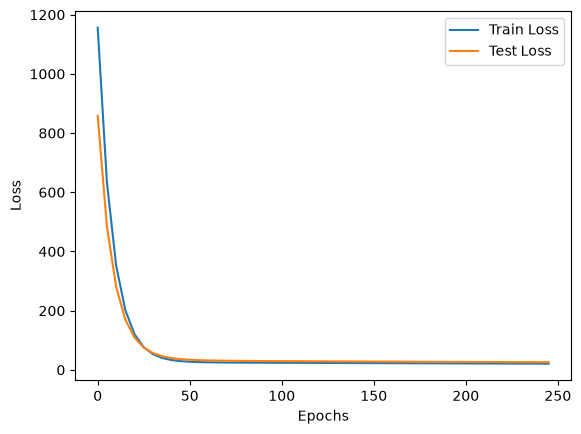

In [39]:
plt.plot(epoch_count, train_loss_values)
plt.plot(epoch_count, test_loss_values)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Test Loss"])
plt.show()

## 22. Inspect learned parameters / Öğrenilen parametreleri incele

**English**

Display the updated weight and bias after training. The weight is the change in predicted grade per extra study hour; the bias is the prediction at zero hours. These describe the fitted relationship, not a causal effect.

**Türkçe**

Eğitimden sonra güncellenen ağırlığı ve bias değerini göster. Ağırlık, bir saat ek çalışma için tahmin edilen not değişimidir; bias, sıfır saatteki tahmindir. Bunlar öğrenilen ilişkiyi ifade eder; nedensel etkiyi göstermez.


In [40]:
model_0.state_dict()

OrderedDict([('weights', tensor([6.2097])), ('bias', tensor([2.2481]))])